In [7]:
from dist_run import load_experiment

params, tables = load_experiment("large/WindyRooms-v1_5runs")
tables = tables.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

In [8]:
from dist_run import save_experiment
save_experiment(tables[None,:], params)

In [2]:
from dist_plot import plot_mean_convergence, plot_state_convergence

plot_mean_convergence(qtables)
plot_state_convergence(qtables, state=36)

KeyboardInterrupt: 

In [6]:
from dist_plot import qr_display_episodes
import numpy as np

state = np.ravel_multi_index((13,0), params.map_size)
qr_display_episodes(tables, params, state=state)

interactive(children=(IntSlider(value=0, description='episode', max=99), Output()), _dom_classes=('widget-inte…

In [2]:
from display_qtables import display_qtables

display_qtables(qtables, params, decimals=1, grid_size=60)

pygame 2.6.1 (SDL 2.28.4, Python 3.10.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [ ]:
from dist_plot import qr_display_episodes_kde

qr_display_episodes_kde(tables, params, state=36, action=3)

interactive(children=(IntSlider(value=0, description='episode', max=199), Output()), _dom_classes=('widget-int…

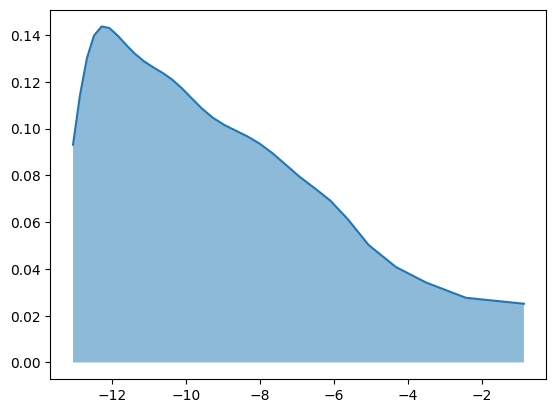

In [27]:
from sklearn.neighbors import KernelDensity
import numpy as np
from matplotlib import pyplot as plt

action = 0
episode = -1

state = np.ravel_multi_index((13,0), params.map_size)
samples = tables[episode,state,action][:, None]
kde = KernelDensity(kernel="gaussian", bandwidth=0.5).fit(samples)
log_pdf = kde.score_samples(samples)
pdf = np.exp(log_pdf)

plt.plot(samples[:,0], pdf)
plt.fill_between(samples[:,0], pdf, alpha=0.5)
plt.show()

In [ ]:
from sklearn.neighbors import KernelDensity
import numpy as np

def qr_pdf_kde(action_quantiles, bandwidth=0.5):
    samples = action_quantiles[:, None]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(samples)
    log_pdf = kde.score_samples(samples)
    pdf = np.exp(log_pdf)
    return samples, pdf

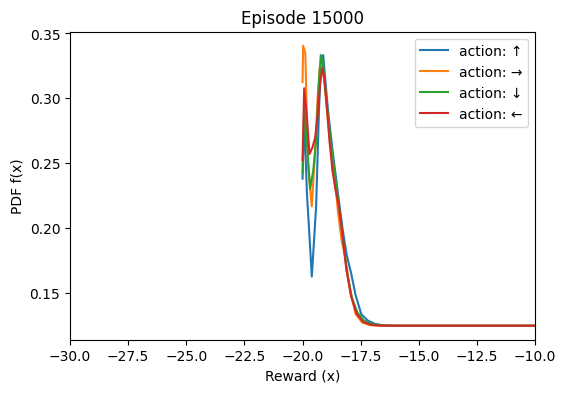

In [ ]:
from sklearn.neighbors import KernelDensity
import numpy as np
import matplotlib.pyplot as plt

def qr_pdf_kde(action_quantiles, bandwidth=0.5):
    samples = action_quantiles.flatten()[:, None]  # shape (n_samples, 1)
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(samples)
    log_pdf = kde.score_samples(samples)
    pdf = np.exp(log_pdf)
    return samples, pdf

ARROW_DIRECTIONS = {0: "↑", 1: "→", 2: "↓", 3: "←"}

def _qr_episodes_kde(tables, params, episode, state, bandwidth=0.1):
    plt.figure(figsize=(6,4))
    
    for j, action_quantiles in enumerate(tables[episode, state]):
        x, pdf = qr_pdf_kde(action_quantiles, bandwidth=bandwidth)
        plt.plot(x, pdf, label=f"action: {ARROW_DIRECTIONS[j]}")
    
    plt.xlabel("Reward (x)")
    plt.ylabel("PDF f(x)")
    plt.title(f"Episode {episode*params.save_skip}")
    plt.legend()
    plt.xlim(-30,-10)
    plt.show()

state = np.ravel_multi_index((2,0), params.map_size)
_qr_episodes_kde(tables, params, 150, state)

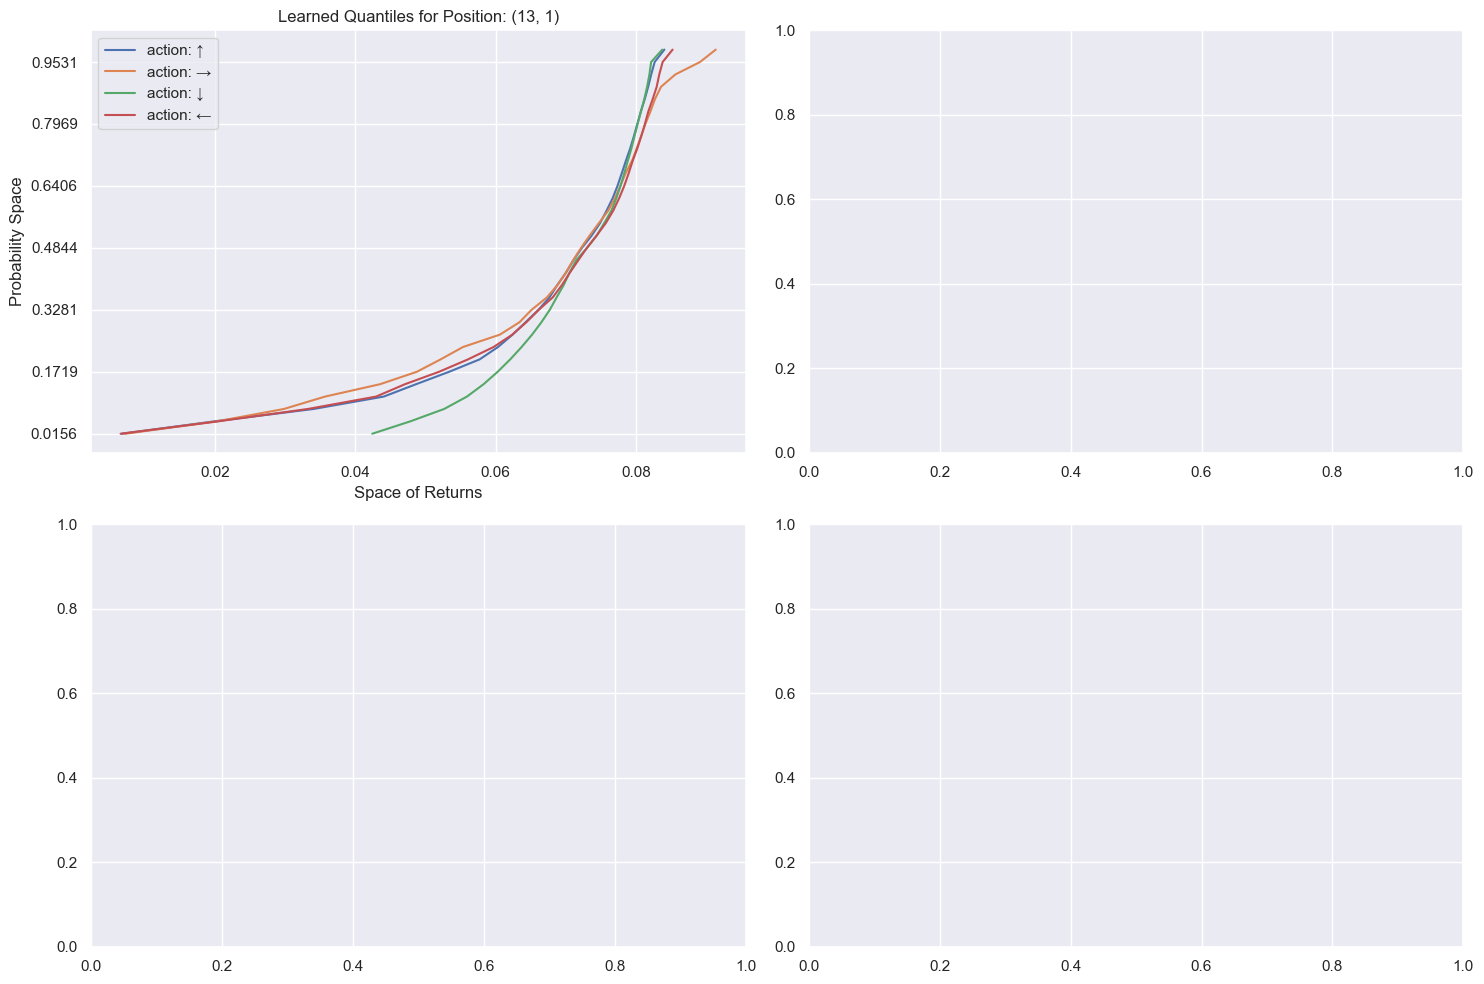

In [ ]:
from dist_plot import plot_cdf_states

plot_cdf_states(tables, params, [(3, 0), (2, 0), (2, 10), (2, 11)])